In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from moabb.paradigms import P300
from moabb.datasets import *


paradigm = P300(resample=48)
dataset = BNCI2014008()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[1],
     return_epochs=True
)
session = meta['session'][1]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]



MNE_DATA is not already configured. It will be set to default location in the home directory - /root/mne_data
All datasets will be downloaded to this location, if anything is already downloaded, please move manually to this location


/usr/local/lib/python3.10/dist-packages/moabb/datasets/download.py:53: RuntimeWarning: Setting non-standard config type: "MNE_DATASETS_BNCI_PATH"
  set_config(key, get_config("MNE_DATA"))


Not setting metadata
4200 matching events found
No baseline correction applied
Not setting metadata
4200 matching events found
No baseline correction applied


In [3]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

X = tl.tensor(epochs.get_data())
y = labels

/tmp/ipykernel_101/3223033590.py:5: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = tl.tensor(epochs.get_data())


In [4]:
#%env PYTHONWARNINGS=error

In [5]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, GreedyBTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler
import warnings
from joblib import parallel_backend
from joblib import Parallel

bttda = BTTDA(
    ranks=[2]*10,
    hoda_params=dict(
        rank=None,
        max_iter=64,
        tol=1e-8,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        random_state=42,
        delta=None,
       
    ),
    verbose=True,
    extra_train_info=True,

)
bttda.fit(X,y)

Fitting block 1/10...


Forward model :  86%|████████▌ | 55/64 [00:03<00:00, 13.80it/s]


Fitting block 2/10...


Forward model :  66%|██████▌   | 42/64 [00:00<00:00, 53.40it/s]


Fitting block 3/10...


...

Fitting block 9/10...


Forward model :  41%|████      | 26/64 [00:00<00:00, 55.10it/s]


Fitting block 10/10...


Forward model :  72%|███████▏  | 46/64 [00:00<00:00, 55.18it/s]


BTTDA(extra_train_info=True,
      hoda_params={'delta': None, 'extra_train_info': False, 'init': 'random',
                   'max_iter': 64, 'obj': 'tr', 'random_state': 42, 'rank': 2,
                   'shrinkage': 'lw', 'solver': 'lanczos', 'taper': False,
                   'toeplitz': None, 'tol': 1e-08, 'verbose': True},
      ranks=[2, 2, 2, 2, 2, 2, 2, 2, 2, 2], verbose=True)

In [6]:
import pandas as pd
df = pd.DataFrame(bttda.train_info_)
df

,block,rank,F_tr,F_rt,log_loss,mse,nmse
0,1,"(2, 2)",0.000070,0.000184,0.353007,1.065801e-10,0.998189
1,2,"(2, 2)",0.000071,0.000185,0.352477,1.064526e-10,0.996995
2,3,"(2, 2)",0.000057,0.000229,0.334177,1.062559e-10,0.995152
3,4,"(2, 2)",0.000046,0.000244,0.327823,1.061223e-10,0.993901
4,5,"(2, 2)",0.000042,0.000251,0.325118,1.059885e-10,0.992648
5,6,"(2, 2)",0.000031,0.000265,0.320693,1.052652e-10,0.985874
6,7,"(2, 2)",0.000030,0.000296,0.309350,1.051011e-10,0.984337
7,8,"(2, 2)",0.000029,0.000297,0.308908,1.048648e-10,0.982124
8,9,"(2, 2)",0.000029,0.000299,0.308066,1.048013e-10,0.981529
9,10,"(2, 2)",0.000028,0.000300,0.307720,1.047721e-10,0.981256


In [7]:
import pandas as pd
df = pd.DataFrame(bttda.train_info_)
df

,block,rank,F_tr,F_rt,log_loss,mse,nmse
0,1,"(2, 2)",0.000070,0.000184,0.353007,1.065801e-10,0.998189
1,2,"(2, 2)",0.000071,0.000185,0.352477,1.064526e-10,0.996995
2,3,"(2, 2)",0.000057,0.000229,0.334177,1.062559e-10,0.995152
3,4,"(2, 2)",0.000046,0.000244,0.327823,1.061223e-10,0.993901
4,5,"(2, 2)",0.000042,0.000251,0.325118,1.059885e-10,0.992648
5,6,"(2, 2)",0.000031,0.000265,0.320693,1.052652e-10,0.985874
6,7,"(2, 2)",0.000030,0.000296,0.309350,1.051011e-10,0.984337
7,8,"(2, 2)",0.000029,0.000297,0.308908,1.048648e-10,0.982124
8,9,"(2, 2)",0.000029,0.000299,0.308066,1.048013e-10,0.981529
9,10,"(2, 2)",0.000028,0.000300,0.307720,1.047721e-10,0.981256


[0.80988308 0.03534432 0.70802483 ... 0.51464783 0.07849753 0.10395739]


<Axes: >

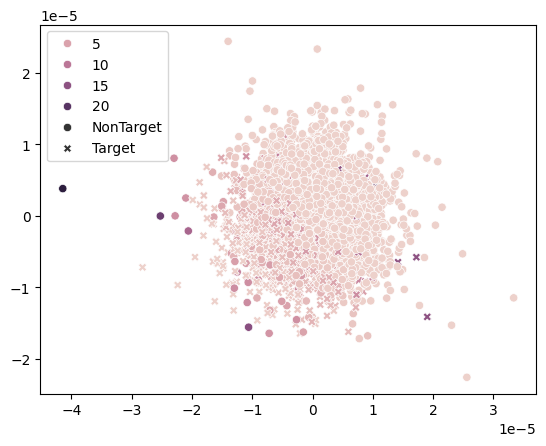

In [8]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA()
Xt = bttda.transform(X)
weight = tl.to_numpy(bttda.calc_weight(Xt,y))
Xt = tl.to_numpy(Xt)
Xt_viz = pca.fit_transform(Xt)
sns.scatterplot(x=Xt_viz[:,0], y=Xt_viz[:,1], style=y, hue=weight)